In [68]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, auc, roc_curve
import pickle

### LOAD DATA + DATA UNDERSTAND

In [43]:
df = pd.read_csv('churn_data.csv')

In [44]:
# to display all columns 
pd.set_option('display.max_columns',None)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
df.shape

(7043, 21)

In [46]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [47]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [48]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [49]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### DATA PREPROCESSING

In [50]:
# DROP UNNECESSARY COLUMNS
df = df.drop(['customerID'], axis=1)

In [51]:
df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [52]:
# step 1 — fix TotalCharges
df['TotalCharges'] = df['TotalCharges'].replace({' ': "0.0"})
df['TotalCharges'] = df['TotalCharges'].astype(float)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [53]:
encoder = LabelEncoder()
for column in df.columns:
    if df[column].dtype == 'object' or str(df[column].dtype) == 'str': 
        df[column] = encoder.fit_transform(df[column])

### DATA VISUALIZATION

In [54]:
# set the desired theme
sns.set_theme(style="darkgrid")

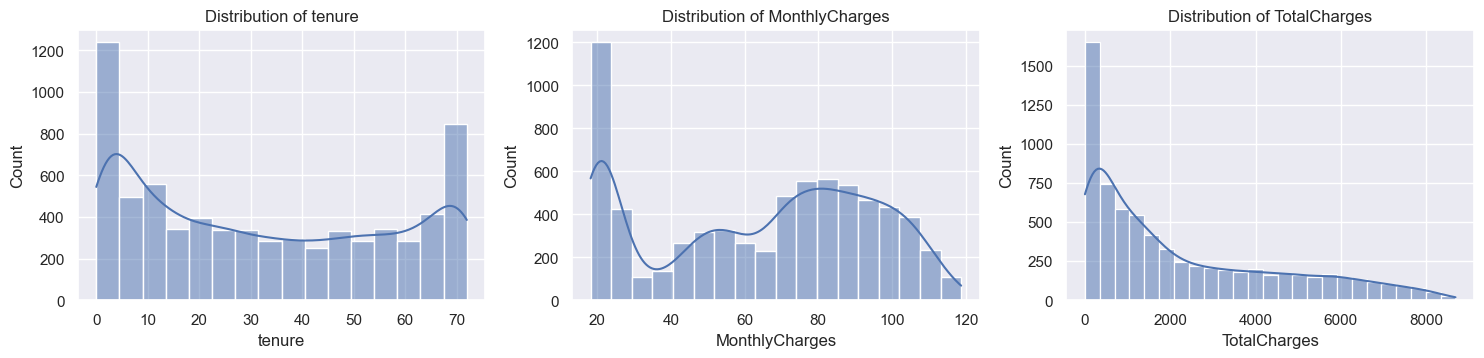

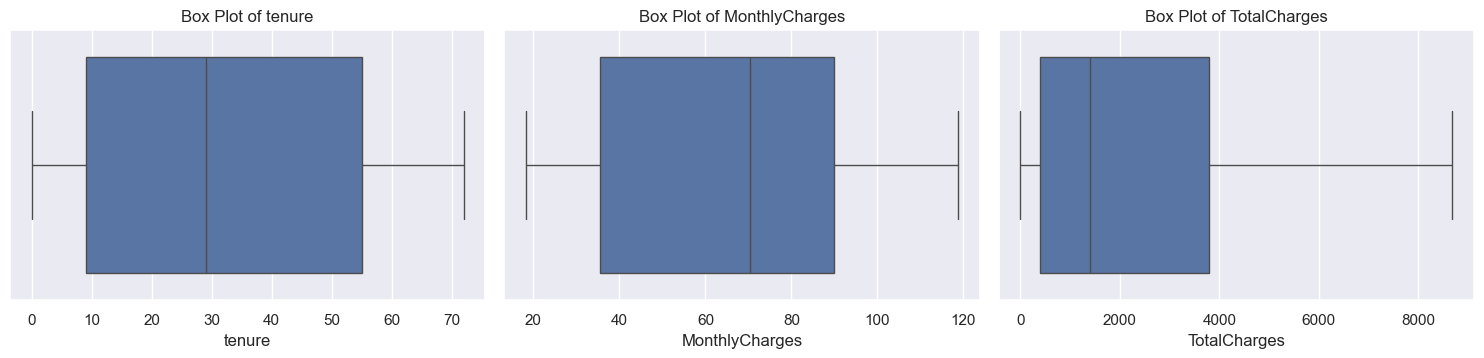

In [55]:
# show the distribution of the data
plt.figure(figsize=(15,10))
for i,column in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges'], 1):
    plt.subplot(3,3,i)
    sns.histplot(df[column],kde=True)
    plt.title(f"Distribution of {column}")
plt.tight_layout()
plt.show()

# show the boxplot of the data
plt.figure(figsize=(15,10))
for i,column in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges'], 1):
    plt.subplot(3,3,i)
    sns.boxplot(x=df[column])
    plt.title(f"Box Plot of {column}")
plt.tight_layout()
plt.show()



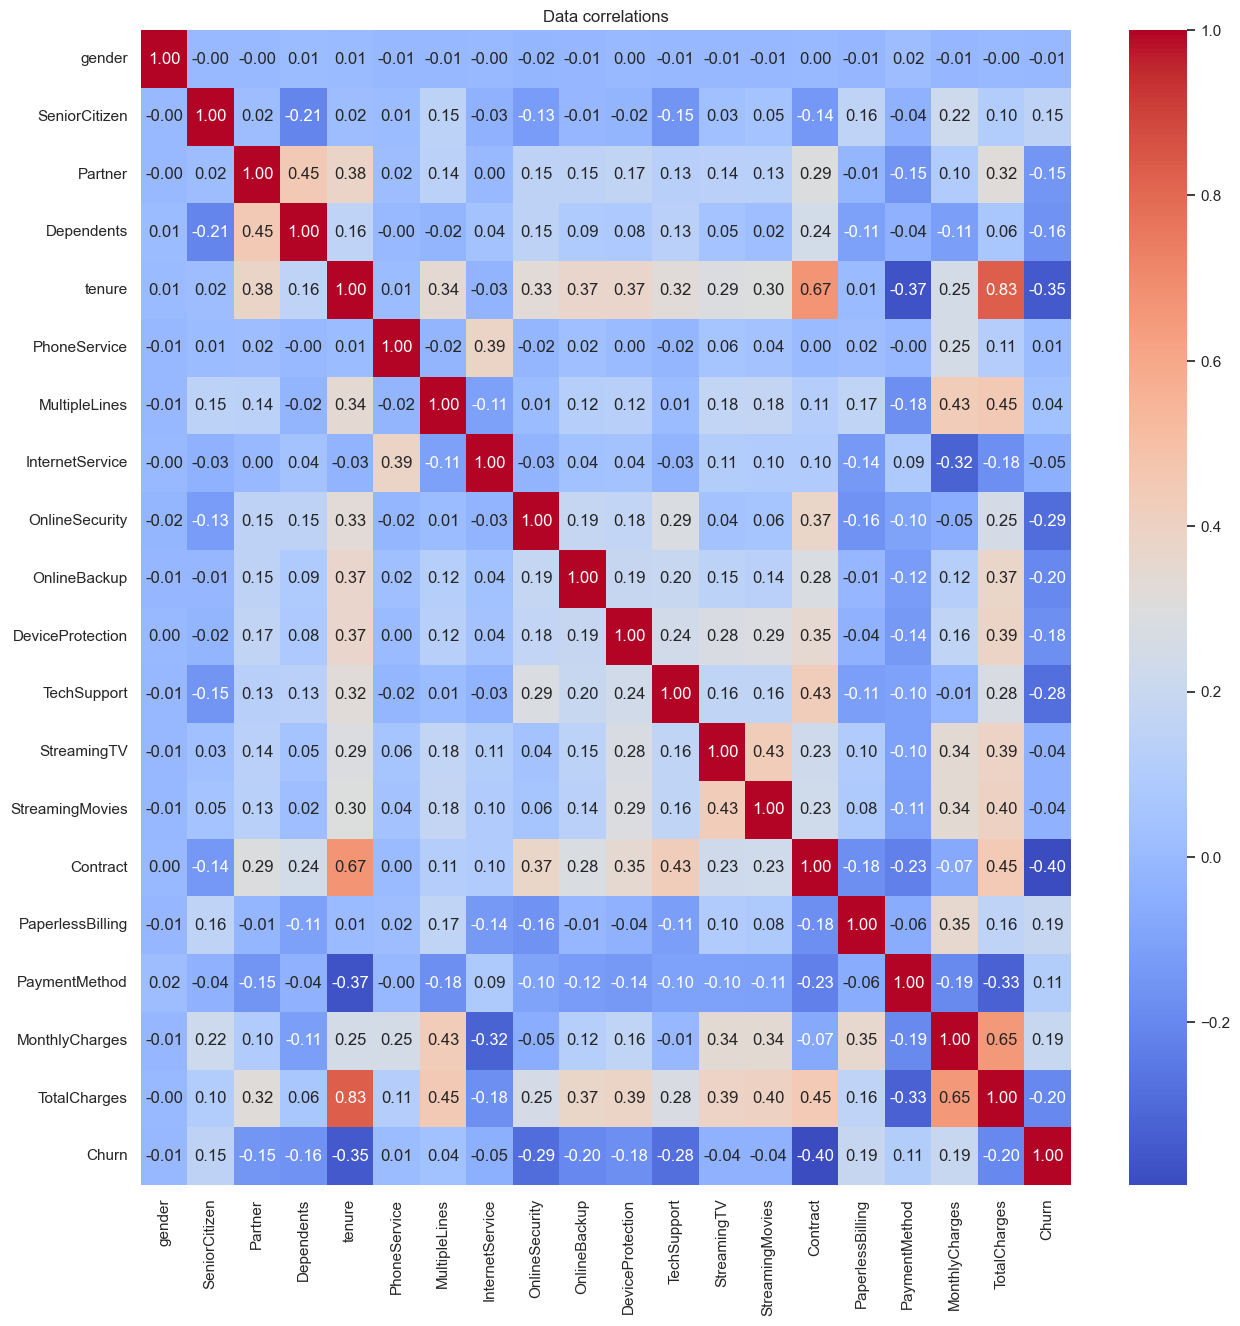

In [56]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap='coolwarm')
plt.title('Data correlations')
plt.show()

> **INSIGHTS**
>   - we encoded columns
>   - "Churn" is unbalance
>   - we droped "customer id" 
>   - No outiers
>   - needed to be standardized --> ['tenure', 'MonthlyCharges', 'TotalCharges']
>---


### DATA SPLITTING

In [57]:
x = df.drop('Churn', axis=1)
y = df['Churn']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [58]:
# only scale numerical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
x_train[numerical_cols] = scaler.fit_transform(x_train[numerical_cols])
x_test[numerical_cols]  = scaler.transform(x_test[numerical_cols])


### MODEL TRAINING

#### models

In [59]:
# models with class_weight balanced
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Decision Tree'      : DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest'      : RandomForestClassifier(class_weight='balanced', random_state=42),
    'SVM'                : SVC(class_weight='balanced', random_state=42, probability=True),
    'XGBoost'            : XGBClassifier(scale_pos_weight=4138/1496, random_state=42)
}

#### hyper parameter tunning

In [60]:
# param distributions for each model
param_dist = {
    'Logistic Regression': {
        'C'      : [0.01, 0.1, 1, 10, 100],
        'solver' : ['lbfgs', 'liblinear']
    },
    'Decision Tree': {
        'max_depth'        : [None, 5, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf' : [1, 2, 4],
        'criterion'        : ['gini', 'entropy']
    },
    'Random Forest': {
        'n_estimators'     : [50, 100, 200, 300],
        'max_depth'        : [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf' : [1, 2, 4],
        'max_features'     : ['sqrt', 'log2']
    },
    'SVM': {
        'C'      : [0.1, 1, 10, 100],
        'kernel' : ['linear', 'rbf'],
        'gamma'  : ['scale', 'auto']
    },
    'XGBoost': {
        'n_estimators' : [50, 100, 200, 300],
        'max_depth'    : [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample'    : [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0]
    }
}

In [69]:
best_models ={}
best_params ={}

# define stratified k-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# loop through each model
for model_name, model in models.items():
    print(f"Tuning {model_name}...")

    random_search = RandomizedSearchCV(
        estimator           = model,
        param_distributions = param_dist[model_name],
        cv                  = skf,
        scoring             = 'f1',   
        n_jobs              = -1,
        random_state        = 42,
        verbose             = 1
    )

    random_search.fit(x_train, y_train)

    best_models[model_name] = random_search.best_estimator_
    best_params[model_name] = random_search.best_params_

    print(f"Best params : {random_search.best_params_}")
    print(f"Best score  : {random_search.best_score_:.2f}")
    print("-" * 50)

Tuning Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params : {'solver': 'liblinear', 'C': 100}
Best score  : 0.62
--------------------------------------------------
Tuning Decision Tree...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params : {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5, 'criterion': 'gini'}
Best score  : 0.61
--------------------------------------------------
Tuning Random Forest...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}
Best score  : 0.62
--------------------------------------------------
Tuning SVM...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params : {'kernel': 'rbf', 'gamma': 'scale', 'C': 0.1}
Best score  : 0.61
--------------------------------------------------
Tuning XGBoost...
Fitting 5 folds for each of 10 cand

### MODEL EVALUATION

In [70]:
for model_name, model in best_models.items():
    cv_scores = cross_val_score(model, x_train, y_train, cv=skf)
    print(f"{model_name:20} → Mean: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

Logistic Regression  → Mean: 0.74 ± 0.01
Decision Tree        → Mean: 0.74 ± 0.01
Random Forest        → Mean: 0.78 ± 0.01
SVM                  → Mean: 0.73 ± 0.01
XGBoost              → Mean: 0.76 ± 0.01



Logistic Regression
Accuracy: 0.76
              precision    recall  f1-score   support

           0       0.93      0.73      0.81      1036
           1       0.52      0.84      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



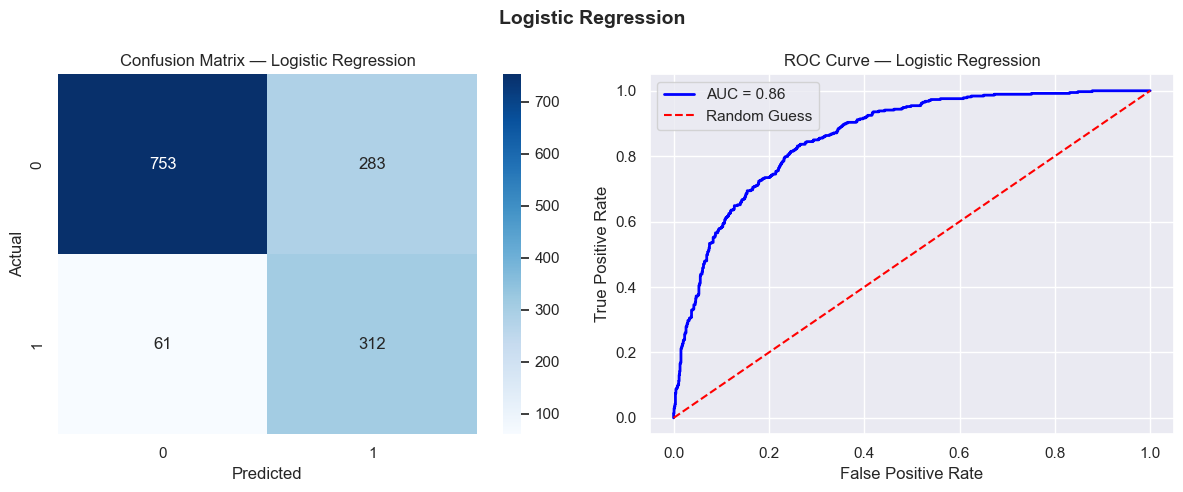


Decision Tree
Accuracy: 0.72
              precision    recall  f1-score   support

           0       0.91      0.69      0.78      1036
           1       0.48      0.81      0.61       373

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.69      1409
weighted avg       0.80      0.72      0.74      1409



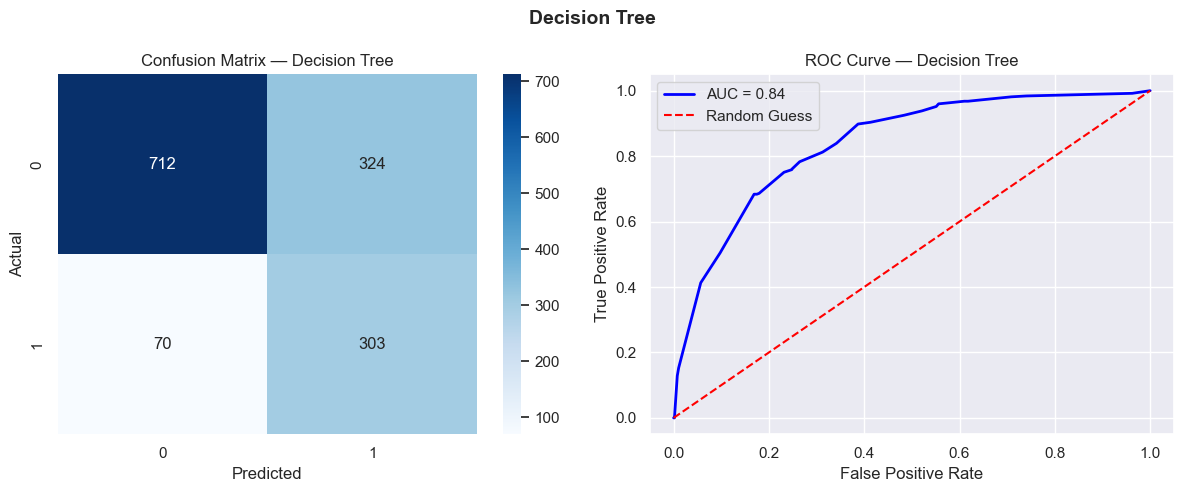


Random Forest
Accuracy: 0.79
              precision    recall  f1-score   support

           0       0.89      0.81      0.85      1036
           1       0.58      0.73      0.65       373

    accuracy                           0.79      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.79      0.80      1409



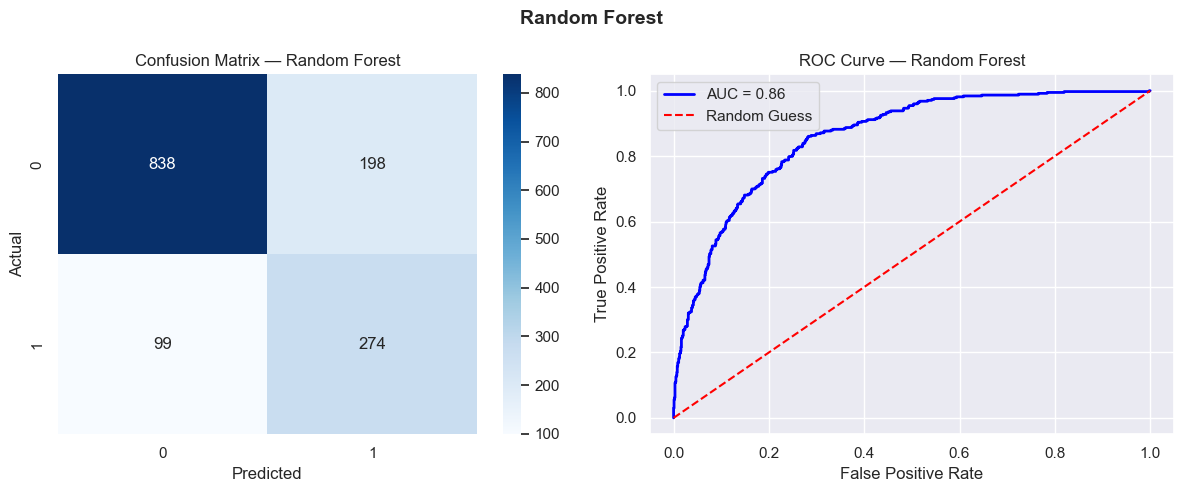


SVM
Accuracy: 0.74
              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1036
           1       0.51      0.81      0.63       373

    accuracy                           0.74      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.74      0.76      1409



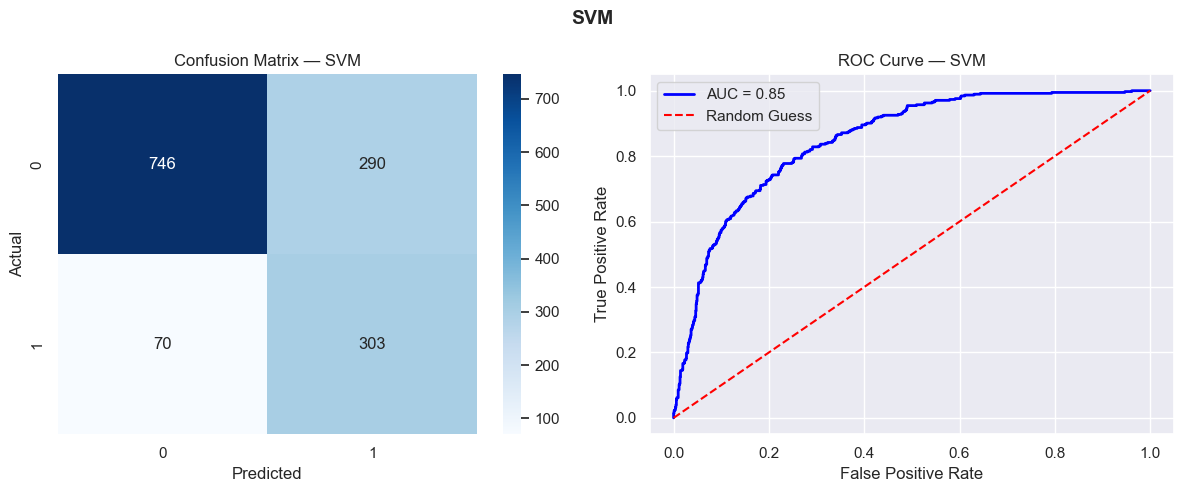


XGBoost
Accuracy: 0.76
              precision    recall  f1-score   support

           0       0.92      0.73      0.82      1036
           1       0.53      0.82      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



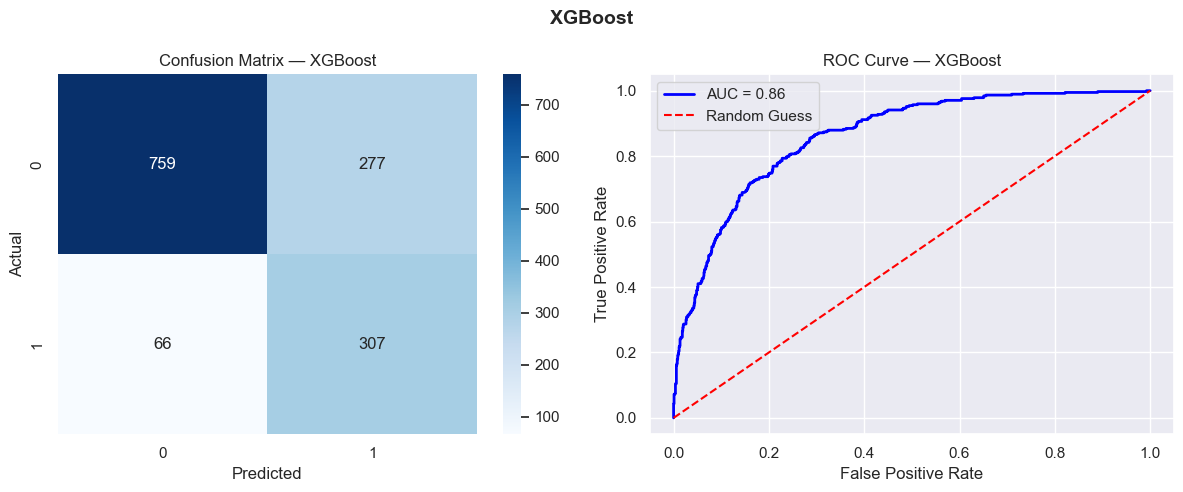

In [71]:
for model_name, model in best_models.items():
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    # accuracy & classification report
    print(f"\n{model_name}")
    print("=" * 50)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))

    # confusion matrix + ROC curve side by side
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # left → confusion matrix
    sns.heatmap(confusion_matrix(y_test, y_pred),annot=True, fmt='d', cmap='Blues',ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {model_name}')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # right → ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score   = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='blue', linewidth=2, label=f'AUC = {auc_score:.2f}')
    axes[1].plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve — {model_name}')
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(model_name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### SAVE MODEL